# F1 Pit Stop Prediction - Feature Engineering

**Kaggle Playground Series S6E5**

We build all features informed by the EDA. Each tier adds progressively more domain-specific signals. The output is a clean train and test parquet ready for modelling.

## 0. Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 110

train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')

print(f'Train: {train.shape}  |  Test: {test.shape}')

Train: (439140, 16)  |  Test: (188165, 15)


## 1. Sort Data (Required for Lag and Rolling Features)

All time-based features need the data sorted by race, driver, and lap number first.

In [4]:
sort_keys = ['Race', 'Year', 'Driver', 'LapNumber']

train = train.sort_values(sort_keys).reset_index(drop=True)
test  = test.sort_values(sort_keys).reset_index(drop=True)

print('Sorted. First few rows:')
train[sort_keys + ['TyreLife', 'PitNextLap']].head(10)

Sorted. First few rows:


,Race,Year,Driver,LapNumber,TyreLife,PitNextLap
0,Abu Dhabi Grand Prix,2022,ALB,1,1.0,0.0
1,Abu Dhabi Grand Prix,2022,ALB,18,7.0,1.0
2,Abu Dhabi Grand Prix,2022,ALB,61,27.0,0.0
3,Abu Dhabi Grand Prix,2022,ALO,1,1.0,0.0
4,Abu Dhabi Grand Prix,2022,ALO,8,8.0,0.0
5,Abu Dhabi Grand Prix,2022,ALO,9,9.0,0.0
6,Abu Dhabi Grand Prix,2022,ALO,10,12.0,1.0
7,Abu Dhabi Grand Prix,2022,ALO,25,25.0,0.0
8,Abu Dhabi Grand Prix,2022,ALO,34,24.0,1.0
9,Abu Dhabi Grand Prix,2022,ANT,43,24.0,0.0


## 2. Tier 1 Features - Highest Impact

These come directly from EDA findings. TyreLife relative to compound norms, degradation rate, race position flags.

In [5]:
def add_tier1_features(df, compound_stats=None, is_train=True):
    df = df.copy()

    # Compound median and std pit windows (fit on train only)
    if is_train:
        compound_stats = df[df['PitNextLap'] == 1].groupby('Compound')['TyreLife'].agg(
            compound_pit_median='median',
            compound_pit_std='std'
        ).reset_index()

    df = df.merge(compound_stats, on='Compound', how='left')

    # How far is this lap from the typical pit window for this compound
    df['TyreLife_vs_PitWindow'] = df['TyreLife'] - df['compound_pit_median']

    # Z-score: how many stds away from typical pit lap
    df['TyreLife_PitWindow_Z'] = df['TyreLife_vs_PitWindow'] / (df['compound_pit_std'] + 1)

    # Are we inside the expected pit window (within 80% of median life)
    df['In_PitWindow'] = (df['TyreLife'] >= df['compound_pit_median'] * 0.75).astype(int)

    # Degradation rate per lap
    df['Deg_Rate'] = df['Cumulative_Degradation'] / (df['TyreLife'] + 1)

    # Laps remaining in race
    df['LapsRemaining'] = 1.0 - df['RaceProgress']

    # Already pitted this race
    df['Already_Pitted'] = (df['Stint'] > 1).astype(int)

    # Race phase flags from EDA
    df['Early_Race'] = (df['RaceProgress'] < 0.12).astype(int)
    df['Late_Race']  = (df['RaceProgress'] > 0.92).astype(int)
    df['Mid_Race']   = ((df['RaceProgress'] >= 0.25) & (df['RaceProgress'] <= 0.75)).astype(int)

    # Position x TyreLife: leader on old tyres is high risk
    df['Position_x_TyreLife'] = df['Position'] * df['TyreLife']

    # Tyre life normalized within compound
    df['TyreLife_norm'] = df['TyreLife'] / df['compound_pit_median']

    return df, compound_stats


train, compound_stats = add_tier1_features(train, is_train=True)
test,  _              = add_tier1_features(test, compound_stats=compound_stats, is_train=False)

tier1_features = [
    'TyreLife_vs_PitWindow', 'TyreLife_PitWindow_Z', 'In_PitWindow',
    'Deg_Rate', 'LapsRemaining', 'Already_Pitted',
    'Early_Race', 'Late_Race', 'Mid_Race',
    'Position_x_TyreLife', 'TyreLife_norm'
]

print(f'Tier 1 features added: {len(tier1_features)}')
train[tier1_features].describe().T[['mean', 'std', 'min', 'max']]

Tier 1 features added: 11


,mean,std,min,max
TyreLife_vs_PitWindow,-3.066215,9.416778,-19.000000,60.000000
TyreLife_PitWindow_Z,-0.294296,0.887036,-1.626182,7.052749
In_PitWindow,0.512404,0.499847,0.000000,1.000000
Deg_Rate,-2.370664,9.189903,-122.579500,1205.000000
LapsRemaining,0.662339,0.253277,0.000000,0.987179
Already_Pitted,0.507474,0.499945,0.000000,1.000000
Early_Race,0.233502,0.423059,0.000000,1.000000
Late_Race,0.019759,0.139171,0.000000,1.000000
Mid_Race,0.454133,0.497892,0.000000,1.000000
Position_x_TyreLife,130.101418,119.986630,1.000000,1216.000000


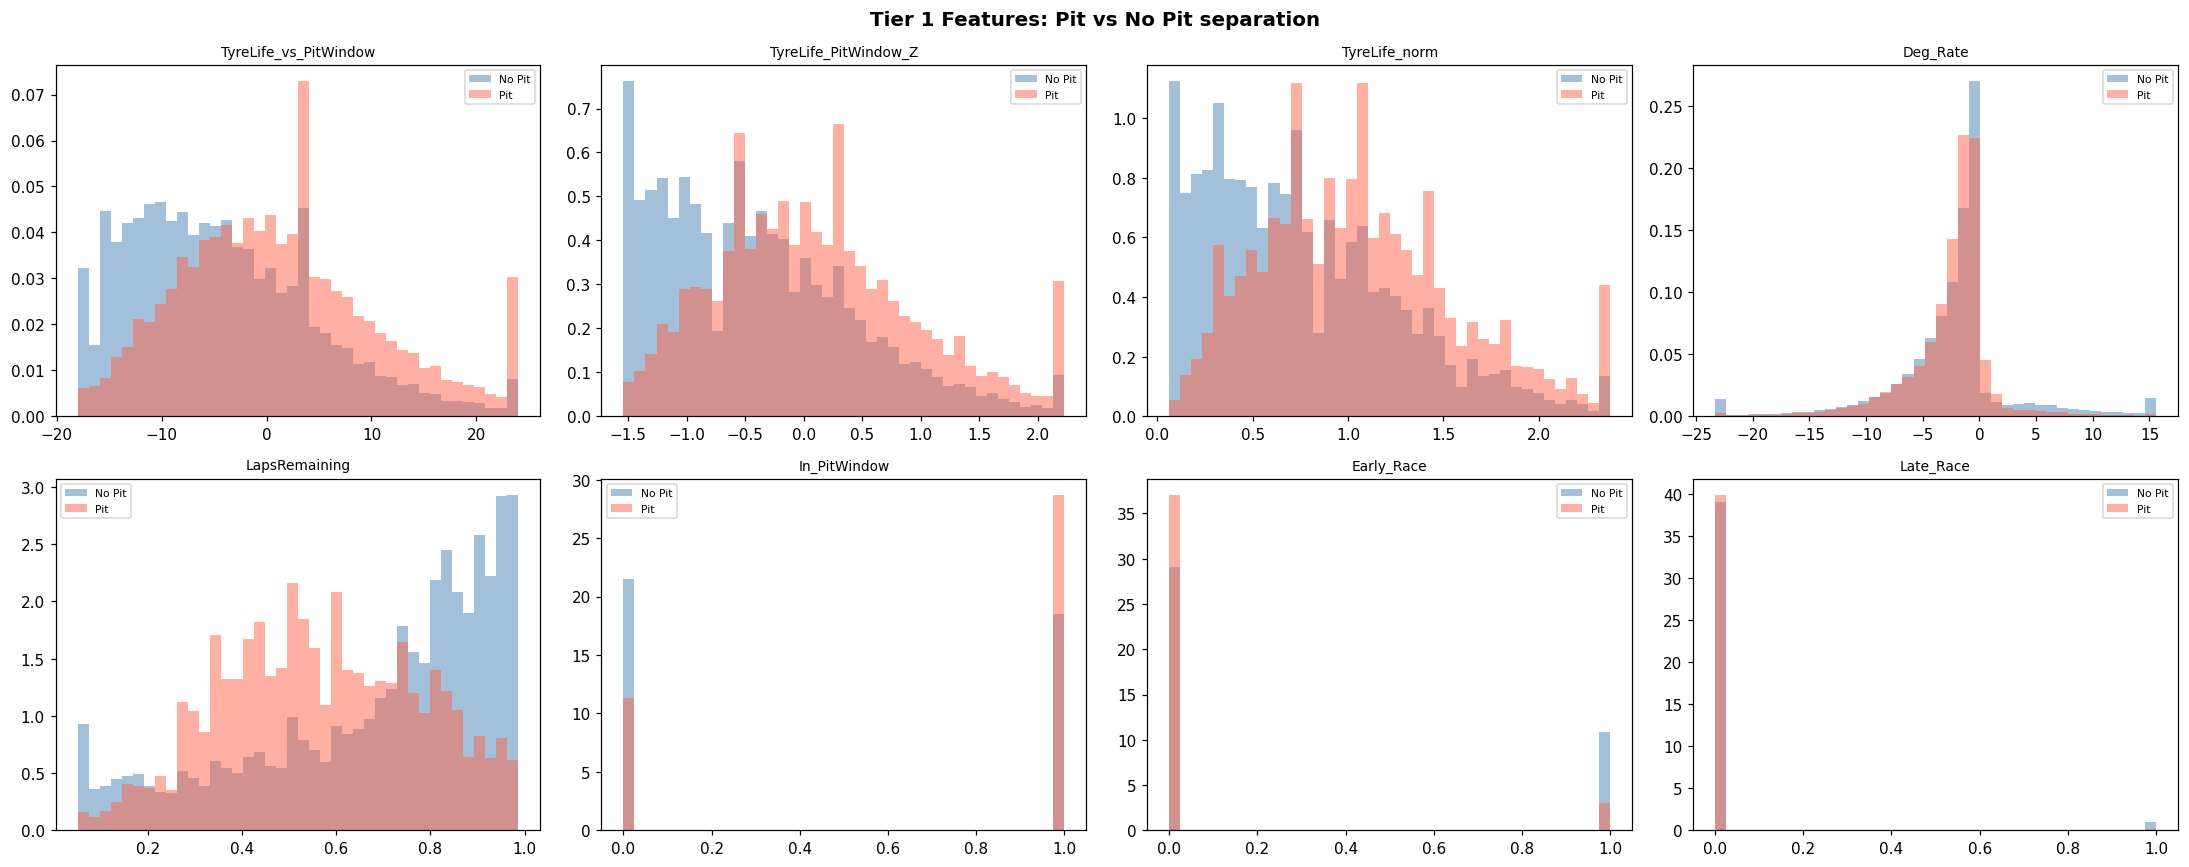

In [6]:
# Quick check: do Tier 1 features separate the classes?
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

check_feats = ['TyreLife_vs_PitWindow', 'TyreLife_PitWindow_Z', 'TyreLife_norm',
               'Deg_Rate', 'LapsRemaining', 'In_PitWindow', 'Early_Race', 'Late_Race']

for i, feat in enumerate(check_feats):
    no_pit = train[train['PitNextLap']==0][feat].clip(
        train[feat].quantile(0.01), train[feat].quantile(0.99))
    pit    = train[train['PitNextLap']==1][feat].clip(
        train[feat].quantile(0.01), train[feat].quantile(0.99))
    axes[i].hist(no_pit, bins=40, alpha=0.5, color='steelblue', label='No Pit', density=True)
    axes[i].hist(pit,    bins=40, alpha=0.5, color='tomato',    label='Pit',    density=True)
    axes[i].set_title(feat, fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle('Tier 1 Features: Pit vs No Pit separation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Tier 2 Features - Rolling and Lag Signals

Time-series features per driver per race. These capture trends in lap time and whether a pit happened recently.

In [7]:
def add_tier2_features(df):
    df = df.copy()
    group = ['Race', 'Year', 'Driver']

    # Rolling lap time stats (last 3 and last 5 laps)
    df['LapTime_Roll3'] = df.groupby(group)['LapTime (s)'].transform(
        lambda x: x.rolling(3, min_periods=1).mean()
    )
    df['LapTime_Roll5'] = df.groupby(group)['LapTime (s)'].transform(
        lambda x: x.rolling(5, min_periods=1).mean()
    )

    # Lap time trend: current lap vs rolling average (positive = slowing down)
    df['LapTime_Trend3'] = df['LapTime (s)'] - df['LapTime_Roll3']
    df['LapTime_Trend5'] = df['LapTime (s)'] - df['LapTime_Roll5']

    # Lap time vs driver own median for this race (normalized to track)
    df['LapTime_vs_Median'] = df.groupby(group)['LapTime (s)'].transform(
        lambda x: x - x.median()
    )

    # Rolling degradation trend
    df['Deg_Roll3'] = df.groupby(group)['Cumulative_Degradation'].transform(
        lambda x: x.rolling(3, min_periods=1).mean()
    )
    df['Deg_Trend'] = df['Cumulative_Degradation'] - df['Deg_Roll3']

    # Lag features: what happened last lap
    df['PitStop_Lag1']     = df.groupby(group)['PitStop'].shift(1).fillna(0)
    df['TyreLife_Lag1']    = df.groupby(group)['TyreLife'].shift(1).fillna(0)
    df['LapTime_Lag1']     = df.groupby(group)['LapTime (s)'].shift(1).fillna(
        df['LapTime (s)'])

    # Laps since last pit stop
    df['Laps_Since_Pit'] = df.groupby(group)['PitStop'].transform(
        lambda x: x.groupby((x != x.shift()).cumsum()).cumcount()
    )

    # Position change trend
    df['PosCh_Roll3'] = df.groupby(group)['Position_Change'].transform(
        lambda x: x.rolling(3, min_periods=1).mean()
    )

    return df


train = add_tier2_features(train)
test  = add_tier2_features(test)

tier2_features = [
    'LapTime_Roll3', 'LapTime_Roll5', 'LapTime_Trend3', 'LapTime_Trend5',
    'LapTime_vs_Median', 'Deg_Roll3', 'Deg_Trend',
    'PitStop_Lag1', 'TyreLife_Lag1', 'LapTime_Lag1',
    'Laps_Since_Pit', 'PosCh_Roll3'
]

print(f'Tier 2 features added: {len(tier2_features)}')
train[tier2_features].describe().T[['mean', 'std', 'min', 'max']]

Tier 2 features added: 12


,mean,std,min,max
LapTime_Roll3,91.545972,21.464743,68.460000,2507.607000
LapTime_Roll5,91.913809,21.993702,68.460000,2507.607000
LapTime_Trend3,-0.597237,10.705750,-1212.821500,1179.572500
LapTime_Trend5,-0.965074,12.002211,-1212.821500,1179.572500
LapTime_vs_Median,1.367142,17.392603,-42.835000,2428.784000
Deg_Roll3,-23.829966,43.508128,-274.417333,2410.000000
Deg_Trend,-1.891792,35.018503,-1221.224500,1635.912667
PitStop_Lag1,0.119946,0.324899,0.000000,1.000000
TyreLife_Lag1,12.156106,9.643960,0.000000,76.000000
LapTime_Lag1,91.626850,25.435202,67.694000,2507.607000


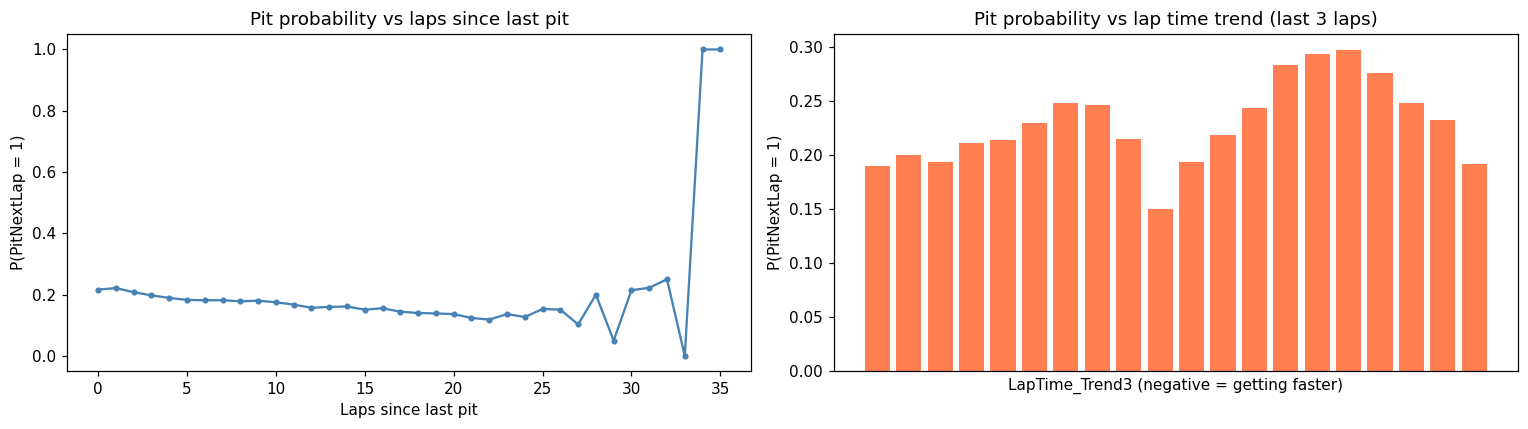

In [8]:
# Pit probability vs laps since last pit
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

laps_pit_rate = train[train['Laps_Since_Pit'] <= 40].groupby('Laps_Since_Pit')['PitNextLap'].mean()
axes[0].plot(laps_pit_rate.index, laps_pit_rate.values, marker='o', markersize=3, color='steelblue')
axes[0].set_title('Pit probability vs laps since last pit')
axes[0].set_xlabel('Laps since last pit')
axes[0].set_ylabel('P(PitNextLap = 1)')

trend_bins = pd.cut(train['LapTime_Trend3'].clip(-5, 5), bins=20)
trend_pit  = train.groupby(trend_bins, observed=True)['PitNextLap'].mean()
axes[1].bar(range(len(trend_pit)), trend_pit.values, color='coral', edgecolor='none')
axes[1].set_title('Pit probability vs lap time trend (last 3 laps)')
axes[1].set_xlabel('LapTime_Trend3 (negative = getting faster)')
axes[1].set_ylabel('P(PitNextLap = 1)')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

## 4. Tier 3 Features - Categorical Encodings

Encode Driver, Race, and Compound. We use target encoding for high-cardinality columns and ordinal encoding for Compound.

In [9]:
from sklearn.preprocessing import TargetEncoder

def add_tier3_features(train_df, test_df):
    train_df = train_df.copy()
    test_df  = test_df.copy()

    # Ordinal encoding for Compound by degradation speed
    compound_map = {'SOFT': 0, 'MEDIUM': 1, 'HARD': 2, 'INTERMEDIATE': 3, 'WET': 4}
    train_df['Compound_enc'] = train_df['Compound'].map(compound_map).fillna(1)
    test_df['Compound_enc']  = test_df['Compound'].map(compound_map).fillna(1)

    # Target encoding for Driver and Race (fit on train only)
    te = TargetEncoder(target_type='binary', smooth='auto', random_state=42)

    train_df['Driver_enc'] = te.fit_transform(
        train_df[['Driver']], train_df['PitNextLap']
    ).ravel()
    test_df['Driver_enc'] = te.transform(test_df[['Driver']]).ravel()

    te2 = TargetEncoder(target_type='binary', smooth='auto', random_state=42)
    train_df['Race_enc'] = te2.fit_transform(
        train_df[['Race']], train_df['PitNextLap']
    ).ravel()
    test_df['Race_enc'] = te2.transform(test_df[['Race']]).ravel()

    # Historical pit rate per driver x compound combination
    driver_compound_rate = (
        train_df.groupby(['Driver', 'Compound'])['PitNextLap']
        .mean()
        .reset_index()
        .rename(columns={'PitNextLap': 'Driver_Compound_PitRate'})
    )
    train_df = train_df.merge(driver_compound_rate, on=['Driver', 'Compound'], how='left')
    test_df  = test_df.merge(driver_compound_rate,  on=['Driver', 'Compound'], how='left')
    test_df['Driver_Compound_PitRate'] = test_df['Driver_Compound_PitRate'].fillna(
        train_df['Driver_Compound_PitRate'].mean()
    )

    return train_df, test_df


train, test = add_tier3_features(train, test)

tier3_features = ['Compound_enc', 'Driver_enc', 'Race_enc', 'Driver_Compound_PitRate']

print(f'Tier 3 features added: {len(tier3_features)}')
train[tier3_features].describe().T

Tier 3 features added: 4


,count,mean,std,min,25%,50%,75%,max
Compound_enc,439140.0,1.388493,0.715331,0.000000,1.000000,1.000000,2.000000,4.000000
Driver_enc,439140.0,0.199034,0.054155,0.000000,0.178298,0.196666,0.218470,0.580199
Race_enc,439140.0,0.198977,0.075123,0.089002,0.142700,0.180943,0.241177,0.392068
Driver_Compound_PitRate,439140.0,0.198982,0.127235,0.000000,0.086957,0.153226,0.335013,1.000000


## 5. Final Feature List

In [10]:
# Raw features we keep
raw_features = [
    'LapNumber', 'Stint', 'TyreLife', 'Position',
    'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
    'RaceProgress', 'Position_Change', 'PitStop', 'Year'
]

all_features = raw_features + tier1_features + tier2_features + tier3_features

# Drop helper columns not used in model
drop_from_model = ['compound_pit_median', 'compound_pit_std']
all_features = [f for f in all_features if f not in drop_from_model]

print(f'Total features: {len(all_features)}')
for i, f in enumerate(all_features):
    print(f'  {i+1:2d}. {f}')

Total features: 38
   1. LapNumber
   2. Stint
   3. TyreLife
   4. Position
   5. LapTime (s)
   6. LapTime_Delta
   7. Cumulative_Degradation
   8. RaceProgress
   9. Position_Change
  10. PitStop
  11. Year
  12. TyreLife_vs_PitWindow
  13. TyreLife_PitWindow_Z
  14. In_PitWindow
  15. Deg_Rate
  16. LapsRemaining
  17. Already_Pitted
  18. Early_Race
  19. Late_Race
  20. Mid_Race
  21. Position_x_TyreLife
  22. TyreLife_norm
  23. LapTime_Roll3
  24. LapTime_Roll5
  25. LapTime_Trend3
  26. LapTime_Trend5
  27. LapTime_vs_Median
  28. Deg_Roll3
  29. Deg_Trend
  30. PitStop_Lag1
  31. TyreLife_Lag1
  32. LapTime_Lag1
  33. Laps_Since_Pit
  34. PosCh_Roll3
  35. Compound_enc
  36. Driver_enc
  37. Race_enc
  38. Driver_Compound_PitRate


In [11]:
# Verify no nulls in features
null_counts = train[all_features].isnull().sum()
print('Null counts in engineered features:')
print(null_counts[null_counts > 0] if null_counts.any() else 'None')

Null counts in engineered features:
None


## 6. Feature Correlation with Target (All Features)

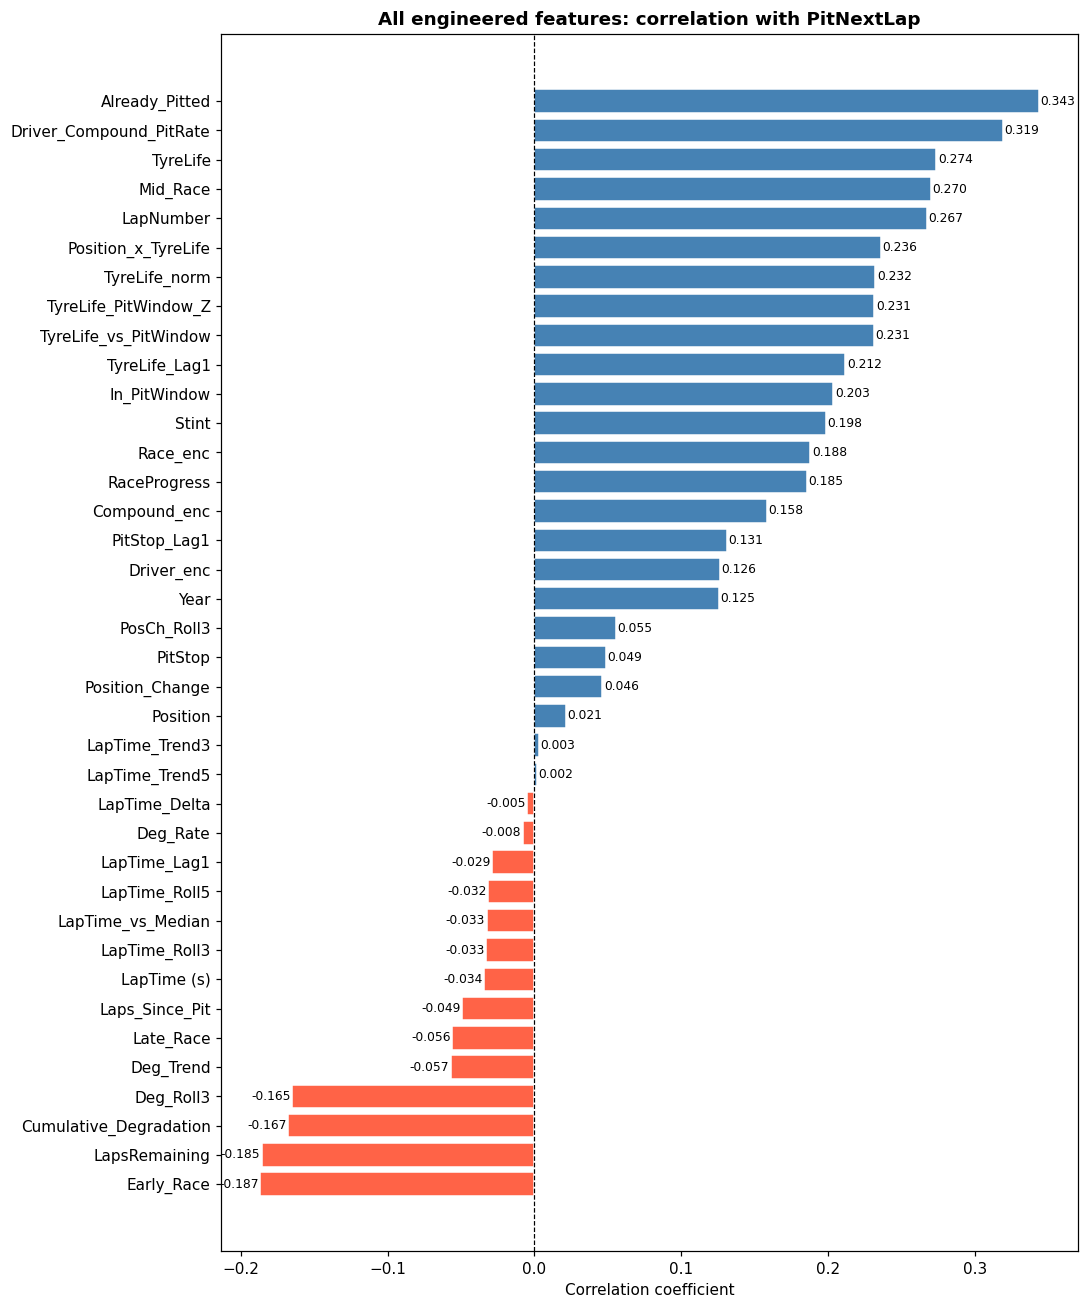

In [12]:
corr_all = train[all_features + ['PitNextLap']].corr()['PitNextLap'].drop('PitNextLap').sort_values()

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['tomato' if x < 0 else 'steelblue' for x in corr_all.values]
ax.barh(corr_all.index, corr_all.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('All engineered features: correlation with PitNextLap', fontsize=12, fontweight='bold')
ax.set_xlabel('Correlation coefficient')
for i, v in enumerate(corr_all.values):
    ax.text(v + (0.001 if v >= 0 else -0.001), i, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.show()

In [13]:
import os
os.makedirs('../data/engineered', exist_ok=True)

# Save feature list
import json
with open('../data/engineered/features.json', 'w') as f:
    json.dump(all_features, f, indent=2)

# Save processed datasets
train[['id'] + all_features + ['PitNextLap']].to_parquet('../data/engineered/train_fe.parquet', index=False)
test[['id']  + all_features].to_parquet('../data/engineered/test_fe.parquet',  index=False)

print('Saved:')
print(f'  train_fe.parquet: {train.shape[0]:,} rows, {len(all_features)} features')
print(f'  test_fe.parquet:  {test.shape[0]:,} rows, {len(all_features)} features')
print(f'  features.json:    {len(all_features)} features listed')

Saved:
  train_fe.parquet: 439,140 rows, 38 features
  test_fe.parquet:  188,165 rows, 38 features
  features.json:    38 features listed
